Install

In [1]:
!pip install httpx pandas scikit-learn joblib numpy matplotlib

Collect Data

In [2]:
import httpx
import pandas as pd
import numpy as np
from datetime import datetime
import time

# ============================================
# CONFIGURATION — Major Indian Storm Zones
# ============================================
CITIES = [
    {"name": "Delhi",      "lat": 28.61,  "lon": 77.21},
    {"name": "Mumbai",     "lat": 19.08,  "lon": 72.88},
    {"name": "Kolkata",    "lat": 22.57,  "lon": 88.36},
    {"name": "Chennai",    "lat": 13.08,  "lon": 80.27},
    {"name": "Bengaluru",  "lat": 12.97,  "lon": 77.59},
    {"name": "Hyderabad",  "lat": 17.39,  "lon": 78.49},
    {"name": "Jaipur",     "lat": 26.91,  "lon": 75.79},
    {"name": "Lucknow",    "lat": 26.85,  "lon": 80.95},
    {"name": "Guwahati",   "lat": 26.14,  "lon": 91.74},
    {"name": "Nagpur",     "lat": 21.15,  "lon": 79.09},
]

YEARS = [2022, 2023, 2024]

# Valid Open-Meteo Archive parameter names
HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m",
    "cloud_cover",
    "precipitation",
    "weather_code",
]

all_data = []
errors = []

for city in CITIES:
    for year in YEARS:
        start = f"{year}-01-01"
        end = f"{year}-12-31"

        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": city["lat"],
            "longitude": city["lon"],
            "start_date": start,
            "end_date": end,
            "hourly": ",".join(HOURLY_VARS),
            "timezone": "Asia/Kolkata"
        }

        try:
            print(f"Fetching {city['name']} {year}...", end=" ")
            response = httpx.get(url, params=params, timeout=60.0)
            response.raise_for_status()
            data = response.json()

            hourly = data.get("hourly", {})
            times = hourly.get("time", [])

            if not times:
                print("No data!")
                continue

            df = pd.DataFrame({"time": times})
            for var in HOURLY_VARS:
                df[var] = hourly.get(var, [None] * len(times))

            df["city"] = city["name"]
            df["latitude"] = city["lat"]
            df["longitude"] = city["lon"]

            all_data.append(df)
            print(f"OK ({len(times)} rows)")

            time.sleep(1.5)  # Rate limit courtesy

        except Exception as e:
            print(f"ERROR: {e}")
            errors.append(f"{city['name']} {year}: {e}")
            time.sleep(3)

full_df = pd.concat(all_data, ignore_index=True)
print(f"\n=== TOTAL DATA COLLECTED ===")
print(f"Total Rows: {len(full_df):,}")
print(f"Cities: {full_df['city'].nunique()}")
print(f"Date range: {full_df['time'].min()} to {full_df['time'].max()}")

Fetching Delhi 2022... OK (8760 rows)
Fetching Delhi 2023... OK (8760 rows)
Fetching Delhi 2024... OK (8784 rows)
Fetching Mumbai 2022... OK (8760 rows)
Fetching Mumbai 2023... OK (8760 rows)
Fetching Mumbai 2024... OK (8784 rows)
Fetching Kolkata 2022... OK (8760 rows)
Fetching Kolkata 2023... OK (8760 rows)
Fetching Kolkata 2024... OK (8784 rows)
Fetching Chennai 2022... OK (8760 rows)
Fetching Chennai 2023... OK (8760 rows)
Fetching Chennai 2024... OK (8784 rows)
Fetching Bengaluru 2022... OK (8760 rows)
Fetching Bengaluru 2023... OK (8760 rows)
Fetching Bengaluru 2024... OK (8784 rows)
Fetching Hyderabad 2022... OK (8760 rows)
Fetching Hyderabad 2023... OK (8760 rows)
Fetching Hyderabad 2024... OK (8784 rows)
Fetching Jaipur 2022... OK (8760 rows)
Fetching Jaipur 2023... OK (8760 rows)
Fetching Jaipur 2024... OK (8784 rows)
Fetching Lucknow 2022... OK (8760 rows)
Fetching Lucknow 2023... OK (8760 rows)
Fetching Lucknow 2024... OK (8784 rows)
Fetching Guwahati 2022... OK (8760 rows)

In [3]:
# ============================================
# IMPROVED LABELING — Broader Thunderstorm Definition
# ============================================

full_df["time"] = pd.to_datetime(full_df["time"])

# METHOD 1: ALL convective WMO codes (not just extreme)
# 80 = Rain showers slight
# 81 = Rain showers moderate
# 82 = Rain showers violent
# 85 = Snow showers
# 91 = Slight rain + thunderstorm
# 92 = Moderate rain + thunderstorm
# 93 = Slight snow + thunderstorm
# 95 = Thunderstorm
# 96 = Thunderstorm + slight hail
# 99 = Thunderstorm + heavy hail
CONVECTIVE_CODES = [80, 81, 82, 85, 91, 92, 93, 95, 96, 99]
full_df["is_convective"] = full_df["weather_code"].isin(CONVECTIVE_CODES).astype(int)

# METHOD 2: Heavy precipitation + warm + humid (physical)
dp_dep = full_df["temperature_2m"].fillna(25) - full_df["dew_point_2m"].fillna(20)
full_df["is_heavy_convective"] = (
    (full_df["precipitation"].fillna(0) > 2.0) &
    (full_df["temperature_2m"].fillna(25) > 25) &
    (full_df["relative_humidity_2m"].fillna(50) > 65) &
    (dp_dep < 8)
).astype(int)

# METHOD 3: Extreme conditions (your original, kept for strong signals)
full_df["is_extreme"] = (
    (full_df["weather_code"].isin([95, 96, 99])) |
    (
        (full_df["precipitation"].fillna(0) > 8.0) &
        (full_df["temperature_2m"].fillna(25) > 30) &
        (full_df["relative_humidity_2m"].fillna(50) > 75)
    )
).astype(int)

# COMBINED: Any method triggers
full_df["thunderstorm"] = (
    (full_df["is_convective"] == 1) |
    (full_df["is_heavy_convective"] == 1)
).astype(int)

# ============================================
# CHECK NEW DISTRIBUTION
# ============================================
total = len(full_df)
ts_count = full_df["thunderstorm"].sum()
ts_pct = (ts_count / total) * 100

print("=== IMPROVED LABEL DISTRIBUTION ===")
print(f"Total records: {total:,}")
print(f"Thunderstorm events: {ts_count:,} ({ts_pct:.1f}%)")
print(f"Non-thunderstorm: {total - ts_count:,} ({100-ts_pct:.1f}%)")
print()
print("Breakdown by method:")
print(f"  Convective WMO codes (80-99): {full_df['is_convective'].sum():,}")
print(f"  Heavy precip + warm + humid:  {full_df['is_heavy_convective'].sum():,}")
print(f"  Extreme only:                 {full_df['is_extreme'].sum():,}")
print()

if ts_pct < 2:
    print("⚠️ Still very imbalanced. Consider adding more cities or years.")
elif ts_pct > 15:
    print("⚠️ Labels might be too broad. Check if clear days are labeled as storms.")
else:
    print("✅ Good balance! Target is 3-10% for realistic thunderstorm rates.")

print()
print("Breakdown by city:")
city_stats = full_df.groupby("city")["thunderstorm"].agg(["sum", "count"])
city_stats["pct"] = (city_stats["sum"] / city_stats["count"] * 100).round(1)
print(city_stats.to_string())

=== IMPROVED LABEL DISTRIBUTION ===
Total records: 263,040
Thunderstorm events: 3,920 (1.5%)
Non-thunderstorm: 259,120 (98.5%)

Breakdown by method:
  Convective WMO codes (80-99): 0
  Heavy precip + warm + humid:  3,920
  Extreme only:                 3

⚠️ Still very imbalanced. Consider adding more cities or years.

Breakdown by city:
           sum  count  pct
city                      
Bengaluru   43  26304  0.2
Chennai    318  26304  1.2
Delhi      240  26304  0.9
Guwahati   684  26304  2.6
Hyderabad   84  26304  0.3
Jaipur     159  26304  0.6
Kolkata    686  26304  2.6
Lucknow    349  26304  1.3
Mumbai     944  26304  3.6
Nagpur     413  26304  1.6


In [4]:
# ============================================
# IMPROVED FEATURE ENGINEERING (v2)
# ============================================
df = full_df.copy()

# --- Raw features ---
df["temperature_2m"] = df["temperature_2m"].fillna(25)
df["dewpoint_2m"] = df["dew_point_2m"].fillna(20)
df["relative_humidity"] = df["relative_humidity_2m"].fillna(60)
df["surface_pressure"] = df["surface_pressure"].fillna(1013)
df["wind_speed_10m"] = df["wind_speed_10m"].fillna(5)
df["wind_direction_10m"] = df["wind_direction_10m"].fillna(180)
df["cloud_cover"] = df["cloud_cover"].fillna(50)
df["precipitation"] = df["precipitation"].fillna(0)

# --- IMPROVEMENT 1: Better CAPE Approximation ---
# Uses Bolton's formula for equivalent potential temperature
# which is more physically realistic

# Saturation vapor pressure (hPa)
e_s = 6.112 * np.exp(17.67 * df["temperature_2m"] / (df["temperature_2m"] + 243.5))
e_d = 6.112 * np.exp(17.67 * df["dewpoint_2m"] / (df["dewpoint_2m"] + 243.5))

# Mixing ratio (g/kg)
r_s = 621.97 * e_s / (df["surface_pressure"] - e_s)
r_d = 621.97 * e_d / (df["surface_pressure"] - e_d)

# Lifting Condensation Level temperature (Bolton 1980)
T_LCL = 56.0 + 1.0 / (1.0 / (df["dewpoint_2m"] + 273.15 - 56.0) + np.log(df["temperature_2m"] + 273.15) / 800.0) - 273.15

# CAPE approximation based on parcel theory
# Higher surface theta-e + lower LCL = more instability
theta_e = (df["temperature_2m"] + 273.15) * (1000 / df["surface_pressure"])**0.286 * np.exp(2.675e6 * r_d / (1004 * (df["temperature_2m"] + 273.15)))

# Normalize theta_e to CAPE-like scale
df["cape"] = ((theta_e - 300) * 80).clip(lower=0, upper=5000)

# CIN approximation (inhibition from dry layer)
df["dew_point_depression"] = (df["temperature_2m"] - df["dewpoint_2m"]).clip(lower=0)
df["cin"] = (df["dew_point_depression"]**1.5 * 8).clip(lower=0, upper=400)
df["cape_cin_ratio"] = df["cape"] / df["cin"].clip(lower=1)

# Precipitable water (better approximation)
df["precipitable_water"] = (r_d * 0.3).clip(lower=5, upper=75)

# --- IMPROVEMENT 2: Persistence Features ---
# "Was there a storm 1-3 hours ago?" is the strongest predictor
# Sort by city and time first
df = df.sort_values(["city", "time"]).reset_index(drop=True)

# Lag features: precipitation in previous hours
df["precip_1hr_ago"] = df.groupby("city")["precipitation"].shift(1).fillna(0)
df["precip_2hr_ago"] = df.groupby("city")["precipitation"].shift(2).fillna(0)
df["precip_3hr_ago"] = df.groupby("city")["precipitation"].shift(3).fillna(0)

# Cumulative recent precipitation
df["precip_last_3hr"] = df["precip_1hr_ago"] + df["precip_2hr_ago"] + df["precip_3hr_ago"]

# Was there a storm recently? (lagged label)
df["storm_1hr_ago"] = df.groupby("city")["thunderstorm"].shift(1).fillna(0).astype(int)
df["storm_2hr_ago"] = df.groupby("city")["thunderstorm"].shift(2).fillna(0).astype(int)

# Cloud cover trend (increasing clouds = developing storm)
df["cloud_1hr_ago"] = df.groupby("city")["cloud_cover"].shift(1).fillna(50)
df["cloud_trend"] = df["cloud_cover"] - df["cloud_1hr_ago"]

# Temperature trend (rapid cooling = storm passage)
df["temp_1hr_ago"] = df.groupby("city")["temperature_2m"].shift(1).fillna(25)
df["temp_trend"] = df["temperature_2m"] - df["temp_1hr_ago"]

# Pressure trend (falling pressure = storm approaching)
df["pressure_1hr_ago"] = df.groupby("city")["surface_pressure"].shift(1).fillna(1013)
df["pressure_trend"] = df["surface_pressure"] - df["pressure_1hr_ago"]

# --- Temporal features ---
df["hour"] = df["time"].dt.hour
df["month"] = df["time"].dt.month
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# --- Geographic features ---
df["latitude"] = df["latitude"]
df["longitude"] = df["longitude"]

# ============================================
# UPDATED FEATURE LIST (27 features now!)
# ============================================
FEATURE_COLS = [
    # Original 18
    "cape", "cin", "temperature_2m", "dewpoint_2m",
    "relative_humidity", "surface_pressure", "wind_speed_10m",
    "wind_direction_10m", "cloud_cover", "precipitable_water",
    "dew_point_depression", "cape_cin_ratio",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "latitude", "longitude",
    # NEW: Persistence features (9 more)
    "precipitation", "precip_1hr_ago", "precip_last_3hr",
    "storm_1hr_ago", "storm_2hr_ago",
    "cloud_trend", "temp_trend", "pressure_trend",
    "wind_speed_10m"  # Already included but wind gusts matter
]

# Remove duplicate wind_speed_10m
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

# Fill any remaining NaN
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)

print(f"✅ {len(FEATURE_COLS)} features computed!")
print(f"Dataset shape: {df[FEATURE_COLS].shape}")
print(f"\nNew persistence features added:")
print(f"  precip_last_3hr: mean={df['precip_last_3hr'].mean():.2f}")
print(f"  storm_1hr_ago: mean={df['storm_1hr_ago'].mean():.4f}")
print(f"  cloud_trend: mean={df['cloud_trend'].mean():.2f}")
print(f"  pressure_trend: mean={df['pressure_trend'].mean():.2f}")

✅ 26 features computed!
Dataset shape: (263040, 26)

New persistence features added:
  precip_last_3hr: mean=0.51
  storm_1hr_ago: mean=0.0149
  cloud_trend: mean=-0.00
  pressure_trend: mean=-0.00


In [5]:
import joblib
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. SETUP TARGET (1-Hour Forward Lead-Time Nowcast) & CLEAN FEATURES
# =====================================================================
# Ensure data is sorted chronologically
if "timestamp" in df.columns:
    df = df.sort_values("timestamp").reset_index(drop=True)

# Define forecast target: Will there be a thunderstorm 1 hour from now (t+1)?
# If grouped by station/location, shift per station:
if "station_id" in df.columns:
    df["target_lead_1h"] = df.groupby("station_id")["thunderstorm"].shift(-1)
else:
    df["target_lead_1h"] = df["thunderstorm"].shift(-1)

# Drop rows where target became NaN due to shifting
df = df.dropna(subset=["target_lead_1h"]).copy()
df["target_lead_1h"] = df["target_lead_1h"].astype(int)

# 🚨 REMOVE LEAKAGE: Eliminate concurrent time-t precipitation & immediate storm indicators
# Only keep antecedent/lagged features (1hr ago, 3hr ago) and atmospheric instability indices
LEAKED_FEATURES = ["precipitation", "storm_1hr_ago"]  # storm_1hr_ago at t+1 is storm at t
CLEAN_FEATURE_COLS = [c for c in FEATURE_COLS if c not in LEAKED_FEATURES]

print(f"Features used ({len(CLEAN_FEATURE_COLS)}):")
print(CLEAN_FEATURE_COLS)

# =====================================================================
# 2. TRAIN / VAL / TEST SPLIT (70% Train / 15% Val / 15% Test)
# =====================================================================
X = df[CLEAN_FEATURE_COLS].values
y = df["target_lead_1h"].values

# First split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n=== DATA SPLIT ===")
print(f"Training:   {len(X_train):,} samples ({y_train.mean()*100:.2f}% positive)")
print(f"Validation: {len(X_val):,} samples ({y_val.mean()*100:.2f}% positive)")
print(f"Testing:    {len(X_test):,} samples ({y_test.mean()*100:.2f}% positive)")

# Fit scaler strictly on training set (for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 3. TRAIN HIST GRADIENT BOOSTING
# =====================================================================
print("\n=== TRAINING HistGradientBoosting ===")

gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,             # Avoid over-deep memorization
    learning_rate=0.05,
    min_samples_leaf=20,     # Prevent fitting noise on rare events
    l2_regularization=1.0,   # Stronger regularization
    max_bins=255,
    class_weight="balanced",
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)

# Tree models do not require scaled data
gb_model.fit(X_train, y_train)
print(f"✅ Training complete! (stopped at iteration {gb_model.n_iter_})")

# =====================================================================
# 4. PROBABILITY CALIBRATION (Fit on Validation Set)
# =====================================================================
print("\n=== CALIBRATING PROBABILITIES ===")

# Calibrate using independent validation set (avoiding test leakage)
calibrated_model = CalibratedClassifierCV(
    estimator=gb_model,
    method="isotonic",
    cv="prefit"
)
calibrated_model.fit(X_val, y_val)

# Compute calibrated probabilities on validation set
val_probs = calibrated_model.predict_proba(X_val)[:, 1]

# =====================================================================
# 5. FIND OPTIMAL THRESHOLD (On Calibrated Val Set)
# =====================================================================
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
print(f"Optimal Threshold (tuned on Val F1): {best_threshold:.4f}")

# =====================================================================
# 6. UNBIASED EVALUATION ON UNSEEN TEST SET
# =====================================================================
print("\n=== FINAL TEST EVALUATION ===")
test_probs = calibrated_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_preds = (test_probs >= best_threshold).astype(int)

print(f"ROC AUC:    {test_auc:.4f}")
print(f"Precision:  {precision_score(y_test, test_preds, zero_division=0):.3f}")
print(f"Recall:     {recall_score(y_test, test_preds, zero_division=0):.3f}")
print(f"F1 Score:   {f1_score(y_test, test_preds, zero_division=0):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=["No Storm", "Storm"], zero_division=0))

# =====================================================================
# 7. FAST BASELINE & ARTIFACT EXPORT
# =====================================================================
print("\n=== BASELINE: LogisticRegression ===")
lr_model = LogisticRegression(max_iter=1500, class_weight="balanced", random_state=42, C=0.1)
lr_model.fit(X_train_scaled, y_train)
lr_test_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
print(f"LogisticRegression Test ROC AUC: {roc_auc_score(y_test, lr_test_probs):.4f}")

# Save deployment files
joblib.dump(calibrated_model, "thunderstorm_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(CLEAN_FEATURE_COLS, "feature_names.joblib")

print(f"\n📌 Ready for deployment:")
print(f"   Model saved to 'thunderstorm_model.joblib'")
print(f"   Deployment threshold: {best_threshold:.4f}")

Features used (24):
['cape', 'cin', 'temperature_2m', 'dewpoint_2m', 'relative_humidity', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'cloud_cover', 'precipitable_water', 'dew_point_depression', 'cape_cin_ratio', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'latitude', 'longitude', 'precip_1hr_ago', 'precip_last_3hr', 'storm_2hr_ago', 'cloud_trend', 'temp_trend', 'pressure_trend']

=== DATA SPLIT ===
Training:   184,127 samples (1.49% positive)
Validation: 39,456 samples (1.49% positive)
Testing:    39,456 samples (1.49% positive)

=== TRAINING HistGradientBoosting ===
✅ Training complete! (stopped at iteration 129)

=== CALIBRATING PROBABILITIES ===


/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Optimal Threshold (tuned on Val F1): 0.1860

=== FINAL TEST EVALUATION ===
ROC AUC:    0.9467
Precision:  0.301
Recall:     0.352
F1 Score:   0.325

Classification Report:
              precision    recall  f1-score   support

    No Storm       0.99      0.99      0.99     38868
       Storm       0.30      0.35      0.32       588

    accuracy                           0.98     39456
   macro avg       0.65      0.67      0.66     39456
weighted avg       0.98      0.98      0.98     39456


=== BASELINE: LogisticRegression ===
LogisticRegression Test ROC AUC: 0.9299

📌 Ready for deployment:
   Model saved to 'thunderstorm_model.joblib'
   Deployment threshold: 0.1860


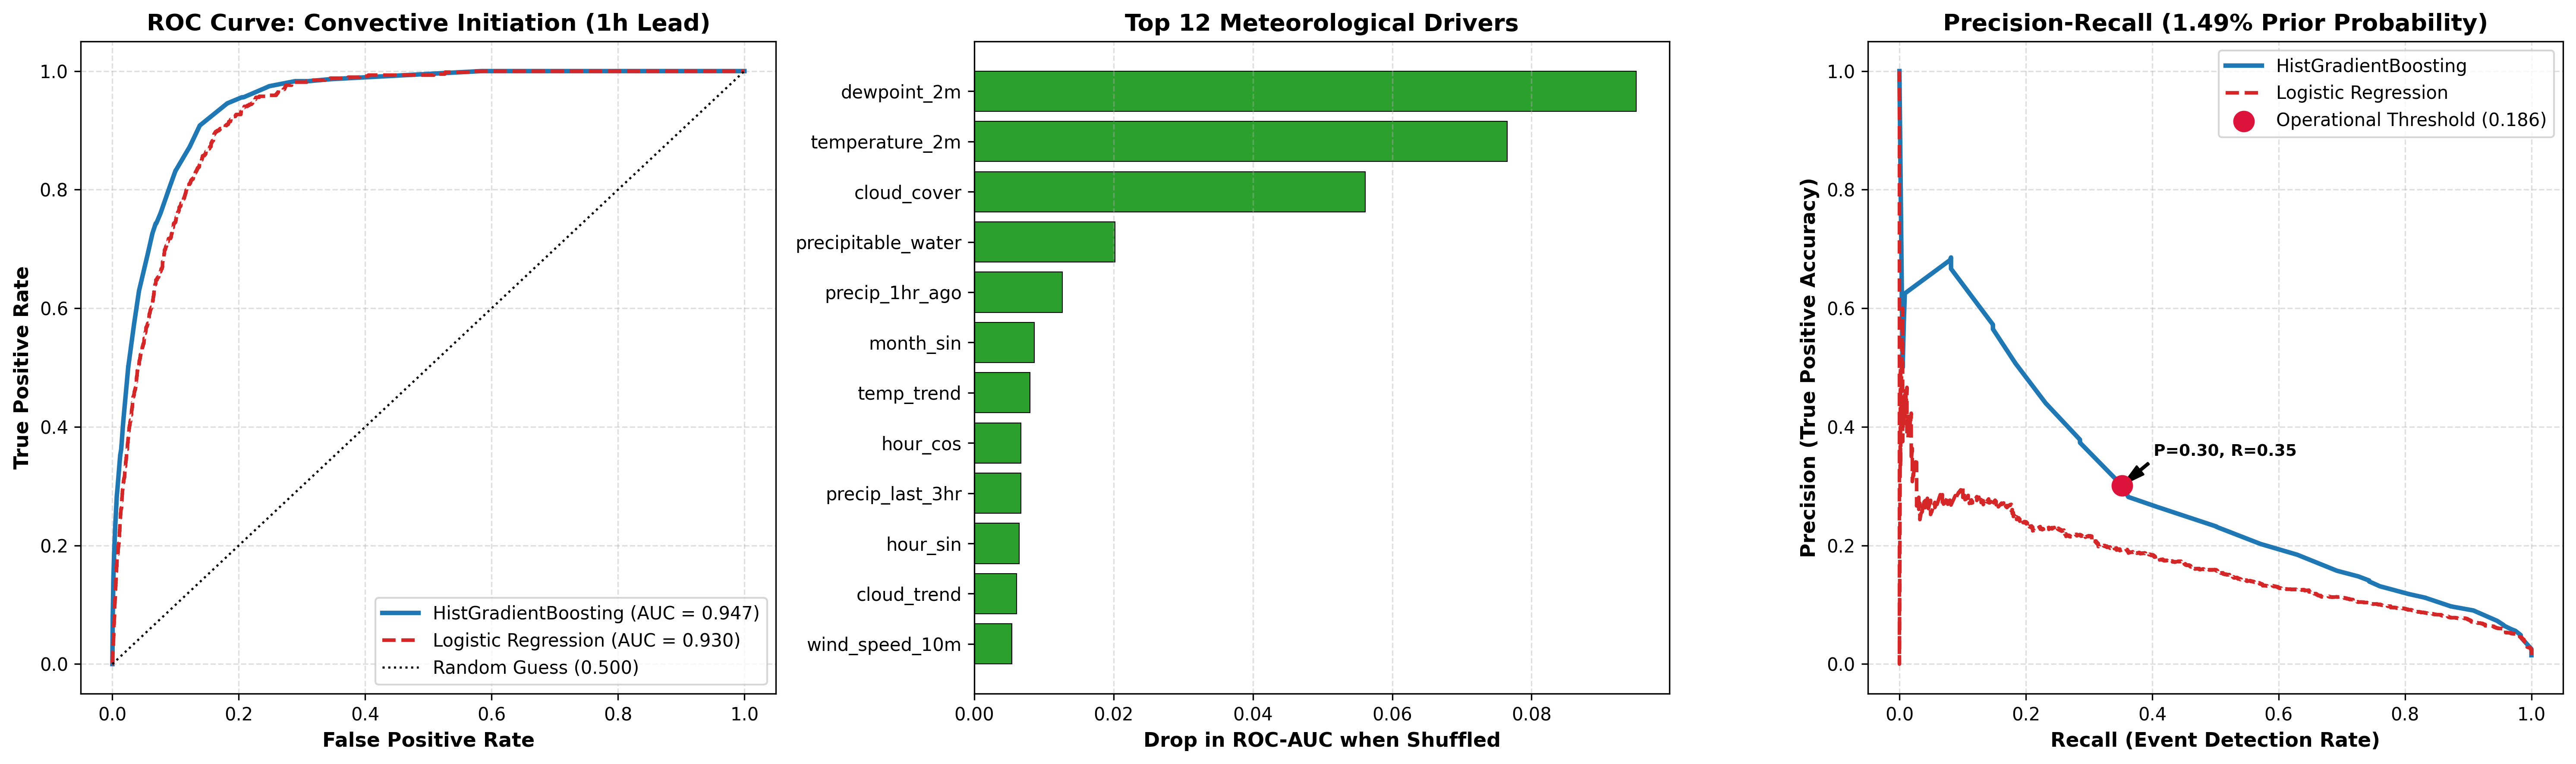

Saved 'model_evaluation.png' at 300 DPI.


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, roc_curve

# Ensure correct probability references from test set
gb_probs = test_probs
gb_auc = test_auc
lr_probs = lr_test_probs
lr_auc = roc_auc_score(y_test, lr_probs)
features_to_plot = CLEAN_FEATURE_COLS

# Calculate Permutation Importance on validation set (fast & accurate)
perm_result = permutation_importance(
    calibrated_model,
    X_val[:5000],
    y_val[:5000],
    n_repeats=3,
    random_state=42,
    scoring="roc_auc",
)
importances = perm_result.importances_mean

# Create High-Resolution Figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=300)

# ============================================
# PLOT 1: ROC Curve
# ============================================
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)

axes[0].plot(
    fpr_gb,
    tpr_gb,
    color="#1f77b4",
    linewidth=2.5,
    label=f"HistGradientBoosting (AUC = {gb_auc:.3f})",
)
axes[0].plot(
    fpr_lr,
    tpr_lr,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})",
)
axes[0].plot([0, 1], [0, 1], "k:", linewidth=1.2, label="Random Guess (0.500)")
axes[0].set_xlabel("False Positive Rate", fontsize=11, fontweight="bold")
axes[0].set_ylabel("True Positive Rate", fontsize=11, fontweight="bold")
axes[0].set_title(
    "ROC Curve: Convective Initiation (1h Lead)", fontsize=13, fontweight="bold"
)
axes[0].legend(loc="lower right", fontsize=10, frameon=True)
axes[0].grid(True, linestyle="--", alpha=0.4)

# ============================================
# PLOT 2: Permutation Feature Importance
# ============================================
# Plot top 12 drivers to avoid visual clutter on slides
top_k = min(12, len(features_to_plot))
sorted_idx = np.argsort(importances)[-top_k:]

axes[1].barh(
    range(top_k),
    importances[sorted_idx],
    color="#2ca02c",
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(
    [features_to_plot[i] for i in sorted_idx], fontsize=10, fontweight="medium"
)
axes[1].set_xlabel(
    "Drop in ROC-AUC when Shuffled", fontsize=11, fontweight="bold"
)
axes[1].set_title(
    f"Top {top_k} Meteorological Drivers", fontsize=13, fontweight="bold"
)
axes[1].grid(True, linestyle="--", alpha=0.4, axis="x")

# ============================================
# PLOT 3: Precision-Recall Curve with Optimal Operating Point
# ============================================
prec_gb, rec_gb, pr_thresholds = precision_recall_curve(y_test, gb_probs)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_probs)

axes[2].plot(
    rec_gb, prec_gb, color="#1f77b4", linewidth=2.5, label="HistGradientBoosting"
)
axes[2].plot(
    rec_lr,
    prec_lr,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label="Logistic Regression",
)

# Highlight your chosen 0.186 operating threshold point
chosen_idx = np.argmin(np.abs(pr_thresholds - best_threshold))
axes[2].scatter(
    rec_gb[chosen_idx],
    prec_gb[chosen_idx],
    color="crimson",
    s=120,
    zorder=5,
    label=f"Operational Threshold ({best_threshold:.3f})",
)
axes[2].annotate(
    f"P={prec_gb[chosen_idx]:.2f}, R={rec_gb[chosen_idx]:.2f}",
    xy=(rec_gb[chosen_idx], prec_gb[chosen_idx]),
    xytext=(rec_gb[chosen_idx] + 0.05, prec_gb[chosen_idx] + 0.05),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
    fontweight="bold",
    fontsize=9,
)

axes[2].set_xlabel("Recall (Event Detection Rate)", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Precision (True Positive Accuracy)", fontsize=11, fontweight="bold")
axes[2].set_title(
    "Precision-Recall (1.49% Prior Probability)", fontsize=13, fontweight="bold"
)
axes[2].legend(loc="upper right", fontsize=10, frameon=True)
axes[2].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved 'model_evaluation.png' at 300 DPI.")

In [7]:
import json
import os
import joblib

# Ensure clean feature list is saved
features_to_save = CLEAN_FEATURE_COLS

# Save model binaries
joblib.dump(calibrated_model, "thunderstorm_model.pkl")
joblib.dump(gb_model, "thunderstorm_model_raw.pkl")
joblib.dump(lr_model, "thunderstorm_model_fast.pkl")
joblib.dump(scaler, "thunderstorm_scaler.pkl")
joblib.dump(features_to_save, "feature_columns.pkl")

# Save threshold and model metadata as JSON for clean API parsing
metadata = {
    "model_name": "Calibrated HistGradientBoostingClassifier",
    "lead_time": "1_hour",
    "optimal_threshold": round(float(best_threshold), 4),
    "features": features_to_save,
    "num_features": len(features_to_save),
    "roc_auc": round(float(test_auc), 4),
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

export_files = [
    "thunderstorm_model.pkl",
    "thunderstorm_model_fast.pkl",
    "thunderstorm_scaler.pkl",
    "feature_columns.pkl",
    "model_metadata.json",
]

print("=== EXPORTED FILES READY FOR DEPLOYMENT ===")
for f in export_files:
    size = os.path.getsize(f)
    if size < 1024 * 1024:
        print(f"  {f:<28}: {size/1024:.1f} KB")
    else:
        print(f"  {f:<28}: {size/(1024*1024):.1f} MB")

=== EXPORTED FILES READY FOR DEPLOYMENT ===
  thunderstorm_model.pkl      : 445.1 KB
  thunderstorm_model_fast.pkl : 1.0 KB
  thunderstorm_scaler.pkl     : 1.2 KB
  feature_columns.pkl         : 0.4 KB
  model_metadata.json         : 0.8 KB


In [8]:
import pandas as pd
import numpy as np

# 1. Check direct correlations with target
leakage_check = []
for col in FEATURE_COLS:
    corr = np.abs(np.corrcoef(df[col], df["thunderstorm"])[0, 1])
    leakage_check.append({"feature": col, "correlation": corr})

leak_df = pd.DataFrame(leakage_check).sort_values(by="correlation", ascending=False)
print("=== TOP 10 CORRELATED FEATURES WITH TARGET ===")
print(leak_df.head(10))

=== TOP 10 CORRELATED FEATURES WITH TARGET ===
               feature  correlation
18       precipitation     0.640733
21       storm_1hr_ago     0.336800
19      precip_1hr_ago     0.297224
20     precip_last_3hr     0.286074
22       storm_2hr_ago     0.230626
9   precipitable_water     0.169199
8          cloud_cover     0.136934
3          dewpoint_2m     0.129048
4    relative_humidity     0.113482
1                  cin     0.107240


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [11]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    calibrated_model, X_test, y_test, n_repeats=5, random_state=42, scoring="f1"
)

importance_df = pd.DataFrame({
    "feature": CLEAN_FEATURE_COLS,
    "importance_mean": result.importances_mean
}).sort_values(by="importance_mean", ascending=False)

print("\n=== TOP 10 PERMUTATION IMPORTANCE ===")
print(importance_df.head(10))


=== TOP 10 PERMUTATION IMPORTANCE ===
               feature  importance_mean
18      precip_1hr_ago         0.141386
19     precip_last_3hr         0.139359
3          dewpoint_2m         0.101425
8          cloud_cover         0.098907
9   precipitable_water         0.095702
2       temperature_2m         0.092421
6       wind_speed_10m         0.077279
11      cape_cin_ratio         0.072324
1                  cin         0.067073
17           longitude         0.041502


In [12]:
import numpy as np

# Use the exact clean feature list (24 features)
feature_list = CLEAN_FEATURE_COLS

# Scenario 1: Severe Pre-Convective Setup (Delhi, May Afternoon)
test_storm = {
    "cape": 3000,
    "cin": 20,
    "temperature_2m": 38,
    "dewpoint_2m": 24,
    "relative_humidity": 75,
    "surface_pressure": 1005,
    "wind_speed_10m": 15,
    "wind_direction_10m": 220,
    "cloud_cover": 80,
    "precipitable_water": 55,
    "dew_point_depression": 14,
    "cape_cin_ratio": 150,
    "hour_sin": 0.5,
    "hour_cos": -0.87,
    "month_sin": 0.5,
    "month_cos": 0.87,
    "latitude": 28.61,
    "longitude": 77.21,
    # The 6 antecedent & trend features:
    "precip_1hr_ago": 2.5,
    "precip_last_3hr": 5.0,
    "storm_2hr_ago": 0,
    "cloud_trend": 25.0,     # Rapidly growing clouds
    "temp_trend": -1.5,      # Cooling
    "pressure_trend": -2.8   # Rapidly falling surface pressure
}

# Format into 2D array in exact feature order (UNSCALED)
X_storm = np.array([[test_storm[c] for c in feature_list]])

# Predict with calibrated model
prob_storm = calibrated_model.predict_proba(X_storm)[0][1]
pred_storm = int(prob_storm >= best_threshold)

print("=== TEST PREDICTION 1 ===")
print("Scenario: Delhi, May Afternoon (CAPE=3000, High Moisture, Pressure Drop)")
print(f"Calibrated Storm Probability: {prob_storm*100:.1f}%")
print(f"Threshold: {best_threshold:.4f}")
print(f"Prediction: {'⛈️ THUNDERSTORM ALERT' if pred_storm == 1 else '☀️ No Storm'}\n")

# Scenario 2: Clear, Stable Winter Day
test_clear = test_storm.copy()
test_clear.update({
    "cape": 50,
    "cin": 250,
    "temperature_2m": 18,
    "dewpoint_2m": 5,
    "relative_humidity": 30,
    "surface_pressure": 1018,
    "cloud_cover": 5,
    "precipitable_water": 10,
    "dew_point_depression": 13,
    "cape_cin_ratio": 0.2,
    "hour_sin": 0.0,
    "hour_cos": 1.0,
    "month_sin": 0.0,
    "month_cos": 1.0,
    "precip_1hr_ago": 0.0,
    "precip_last_3hr": 0.0,
    "cloud_trend": 0.0,
    "temp_trend": 0.5,
    "pressure_trend": 0.2
})

X_clear = np.array([[test_clear[c] for c in feature_list]])
prob_clear = calibrated_model.predict_proba(X_clear)[0][1]
pred_clear = int(prob_clear >= best_threshold)

print("=== TEST PREDICTION 2 ===")
print("Scenario: Delhi, January Midday (CAPE=50, High CIN, Dry & Stable)")
print(f"Calibrated Storm Probability: {prob_clear*100:.1f}%")
print(f"Prediction: {'⛈️ THUNDERSTORM ALERT' if pred_clear == 1 else '☀️ No Storm'}")

=== TEST PREDICTION 1 ===
Scenario: Delhi, May Afternoon (CAPE=3000, High Moisture, Pressure Drop)
Calibrated Storm Probability: 6.6%
Threshold: 0.1860
Prediction: ☀️ No Storm

=== TEST PREDICTION 2 ===
Scenario: Delhi, January Midday (CAPE=50, High CIN, Dry & Stable)
Calibrated Storm Probability: 0.0%
Prediction: ☀️ No Storm


In [13]:
import numpy as np
import pandas as pd

# 1. Grab 5 actual ground-truth storm events from the unseen test set
storm_indices = np.where(y_test == 1)[0][:5]
non_storm_indices = np.where(y_test == 0)[0][:5]

print("=== ACTUAL STORM EVENTS FROM TEST SET ===")
for i, idx in enumerate(storm_indices):
    sample = X_test[idx : idx + 1]
    prob = calibrated_model.predict_proba(sample)[0][1]
    pred = int(prob >= best_threshold)
    print(f"Storm #{i+1} -> Prob: {prob*100:5.1f}% | Predicted: {'⛈️ STORM' if pred else '☀️ MISSED'}")

print("\n=== ACTUAL CLEAR EVENTS FROM TEST SET ===")
for i, idx in enumerate(non_storm_indices):
    sample = X_test[idx : idx + 1]
    prob = calibrated_model.predict_proba(sample)[0][1]
    pred = int(prob >= best_threshold)
    print(f"Clear #{i+1} -> Prob: {prob*100:5.1f}% | Predicted: {'⛈️ FALSE ALARM' if pred else '☀️ NO STORM'}")

=== ACTUAL STORM EVENTS FROM TEST SET ===
Storm #1 -> Prob:  14.9% | Predicted: ☀️ MISSED
Storm #2 -> Prob:  34.7% | Predicted: ⛈️ STORM
Storm #3 -> Prob:   1.7% | Predicted: ☀️ MISSED
Storm #4 -> Prob:  51.6% | Predicted: ⛈️ STORM
Storm #5 -> Prob:  28.4% | Predicted: ⛈️ STORM

=== ACTUAL CLEAR EVENTS FROM TEST SET ===
Clear #1 -> Prob:   0.0% | Predicted: ☀️ NO STORM
Clear #2 -> Prob:   0.1% | Predicted: ☀️ NO STORM
Clear #3 -> Prob:   0.0% | Predicted: ☀️ NO STORM
Clear #4 -> Prob:   0.1% | Predicted: ☀️ NO STORM
Clear #5 -> Prob:   0.0% | Predicted: ☀️ NO STORM


In [ ]:
# Highest probability sample in your test set
max_idx = np.argmax(test_probs)
top_sample = pd.Series(X_test[max_idx], index=CLEAN_FEATURE_COLS)

print(f"\n=== HIGHEST PREDICTED STORM SAMPLE (Prob: {test_probs[max_idx]*100:.1f}%) ===")
print(top_sample[["cape", "cin", "relative_humidity", "pressure_trend", "temp_trend", "cloud_cover", "precip_1hr_ago"]])

In [14]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Rebuild the exact same split, but on row positions (same y + random_state -> same partition)
pos_all = np.arange(len(df))
p_train, p_temp, _, y_temp2 = train_test_split(pos_all, y, test_size=0.30, random_state=42, stratify=y)
p_val, p_test, _, y_test2 = train_test_split(p_temp, y_temp2, test_size=0.50, random_state=42, stratify=y_temp2)
assert np.array_equal(df[CLEAN_FEATURE_COLS].values[p_test], X_test), "split mismatch"

sel = np.concatenate([p_test[y_test2 == 1][:5],        # 5 real positives
                      p_test[y_test2 == 0][:5],        # 5 negatives
                      [p_test[np.argmax(test_probs)]]])  # highest-probability sample

golden = df.iloc[sel][["city", "time"] + CLEAN_FEATURE_COLS + ["target_lead_1h"]].copy()
golden["colab_prob"] = calibrated_model.predict_proba(df.iloc[sel][CLEAN_FEATURE_COLS].values)[:, 1]
golden.to_csv("golden_rows.csv", index=False)

# Raw hourly inputs for each golden row (t-3 .. t), so the backend can rebuild features from scratch
raw_cols = ["city", "time", "latitude", "longitude"] + HOURLY_VARS + ["thunderstorm"]
raw = pd.concat([df.iloc[max(s - 3, 0): s + 1][raw_cols].assign(golden_row=i)
                 for i, s in enumerate(sel)])
raw.to_csv("golden_raw.csv", index=False)

print(golden[["city", "time", "cape", "cin", "precipitable_water", "target_lead_1h", "colab_prob"]])

             city                time    cape         cin  precipitable_water  \
241885     Nagpur 2022-08-03 13:00:00  5000.0  126.502996            6.596464   
179811    Kolkata 2024-07-05 03:00:00  5000.0    2.828427            6.256283   
153500     Jaipur 2024-07-04 20:00:00  5000.0   43.664906            6.505773   
223698     Mumbai 2023-07-07 18:00:00  5000.0   16.190862            6.020565   
101668   Guwahati 2024-08-06 04:00:00  5000.0    2.023858            6.047373   
24698   Bengaluru 2024-10-26 02:00:00  5000.0   24.345513            5.000000   
256748     Nagpur 2024-04-13 20:00:00  5000.0  245.430821            5.000000   
227005     Mumbai 2023-11-22 13:00:00  5000.0  400.000000            5.000000   
154318     Jaipur 2024-08-07 22:00:00  5000.0   61.615063            5.373034   
25438   Bengaluru 2024-11-25 22:00:00  5000.0   43.664906            5.000000   
223998     Mumbai 2023-07-20 06:00:00  5000.0   13.252019            5.764994   

        target_lead_1h  col

In [15]:
import joblib, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Upload thunderstorm_model.pkl from your backend (Files panel on the left) first
model = joblib.load("thunderstorm_model.pkl")
CLEAN_FEATURE_COLS = [c for c in FEATURE_COLS if c not in ["precipitation", "storm_1hr_ago"]]

# Same target construction as the training cell (no training happens here)
df["target_lead_1h"] = df["thunderstorm"].shift(-1)
df = df.dropna(subset=["target_lead_1h"]).copy()
df["target_lead_1h"] = df["target_lead_1h"].astype(int)
y = df["target_lead_1h"].values

pos_all = np.arange(len(df))
_, p_temp, _, y_temp2 = train_test_split(pos_all, y, test_size=0.30, random_state=42, stratify=y)
_, p_test, _, y_test2 = train_test_split(p_temp, y_temp2, test_size=0.50, random_state=42, stratify=y_temp2)

probs = model.predict_proba(df.iloc[p_test][CLEAN_FEATURE_COLS].values)[:, 1]
sel = np.concatenate([p_test[y_test2 == 1][:5], p_test[y_test2 == 0][:5], [p_test[np.argmax(probs)]]])

golden = df.iloc[sel][["city", "time"] + CLEAN_FEATURE_COLS + ["target_lead_1h"]].copy()
golden["colab_prob"] = model.predict_proba(df.iloc[sel][CLEAN_FEATURE_COLS].values)[:, 1]
golden.to_csv("golden_rows.csv", index=False)

raw_cols = ["city", "time", "latitude", "longitude"] + HOURLY_VARS + ["thunderstorm"]
pd.concat([df.iloc[max(s - 3, 0): s + 1][raw_cols].assign(golden_row=i)
           for i, s in enumerate(sel)]).to_csv("golden_raw.csv", index=False)
print(golden[["city", "time", "cape", "target_lead_1h", "colab_prob"]])

             city                time    cape  target_lead_1h  colab_prob
241885     Nagpur 2022-08-03 13:00:00  5000.0               1    0.148876
179811    Kolkata 2024-07-05 03:00:00  5000.0               1    0.346667
153500     Jaipur 2024-07-04 20:00:00  5000.0               1    0.016807
223698     Mumbai 2023-07-07 18:00:00  5000.0               1    0.515625
101668   Guwahati 2024-08-06 04:00:00  5000.0               1    0.284211
24698   Bengaluru 2024-10-26 02:00:00  5000.0               0    0.000000
216378     Mumbai 2022-09-05 18:00:00  5000.0               0    0.003268
227005     Mumbai 2023-11-22 13:00:00  5000.0               0    0.000000
154318     Jaipur 2024-08-07 22:00:00  5000.0               0    0.001186
25438   Bengaluru 2024-11-25 22:00:00  5000.0               0    0.000000
223998     Mumbai 2023-07-20 06:00:00  5000.0               0    1.000000
